# TinyAya MapHallu — Analysis Notebook

Evaluation of four TinyAya model variants (global, earth, fire, water) across
hallucination rate, cross-model disagreement, answer match rate, and prompt sensitivity.

In [1]:
import re
import sys
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

rc_defaults = {
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
    "lines.markersize": 6,
    "figure.dpi": 150,
    "savefig.dpi": 150,
}
plt.rcParams.update(rc_defaults)

MODEL_PALETTE = {
    "global": "#5B8DB8",
    "fire": "#E45756",
    "earth": "#E07B54",
    "water": "#6BAE8E",
}
MODEL_ORDER = ["global", "earth", "fire", "water"]
LANG_ORDER = ["en", "ar", "de", "ru", "th", "zh"]


def short_model(name: str) -> str:
    return name.replace("tiny-aya-", "")


DATA_ROOT = Path("../run_experiments/output")
SKIP_DIRS = {"water_base_20260322_051223"}
OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
sys.path.insert(0, ".")
from load_data import load_all

mkqa_base, xnli_base, mkqa_pss = load_all(DATA_ROOT, skip=SKIP_DIRS)

for df in [mkqa_base, xnli_base, mkqa_pss]:
    df["model"] = df["model"].map(short_model)

print("mkqa_base:", mkqa_base.shape)
print(mkqa_base["model"].value_counts())
print(mkqa_base["language"].value_counts())
print()
print("xnli_base:", xnli_base.shape)
print(xnli_base["model"].value_counts())
print(xnli_base["language"].value_counts())
print()
print("mkqa_pss:", mkqa_pss.shape)
print(mkqa_pss["model"].value_counts())
print(mkqa_pss["language"].value_counts())

Loading 4 runs: ['earth_20260322_183145', 'fire_20260323_135908', 'global_20260321_172527', 'water_20260322_051223']
mkqa_base: (36000, 18)
model
earth     9000
fire      9000
global    9000
water     9000
Name: count, dtype: int64
language
ar    6000
de    6000
en    6000
ru    6000
th    6000
zh    6000
Name: count, dtype: int64

xnli_base: (48000, 18)
model
earth     12000
fire      12000
global    12000
water     12000
Name: count, dtype: int64
language
ar    6000
de    6000
en    6000
hi    6000
ru    6000
sw    6000
th    6000
zh    6000
Name: count, dtype: int64

mkqa_pss: (180000, 18)
model
earth     45000
fire      45000
global    45000
water     45000
Name: count, dtype: int64
language
ar    30000
de    30000
en    30000
ru    30000
th    30000
zh    30000
Name: count, dtype: int64


## Hallucination Rate

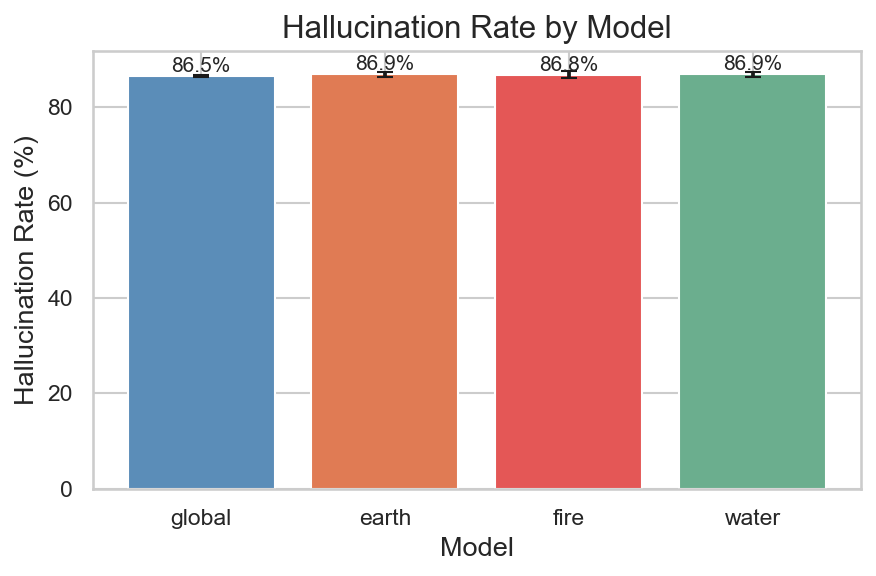

In [3]:
# Hallucination Rate by model (mean ± std across reps)
hr_per_rep = (
    mkqa_base.groupby(["model", "rep"])["is_correct"]
    .mean()
    .rename("accuracy")
    .reset_index()
)
hr_per_rep["hallucination_rate"] = (1 - hr_per_rep["accuracy"]) * 100
hr_model = hr_per_rep.groupby("model")["hallucination_rate"].agg(["mean", "std"]).reindex(MODEL_ORDER).reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(hr_model["model"], hr_model["mean"],
              yerr=hr_model["std"], capsize=4,
              color=[MODEL_PALETTE[m] for m in hr_model["model"]])
ax.set_title("Hallucination Rate by Model")
ax.set_ylabel("Hallucination Rate (%)")
ax.set_xlabel("Model")
for bar, val in zip(bars, hr_model["mean"]):
    ax.annotate(f"{val:.1f}%",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "hr_by_model.png")
plt.show()

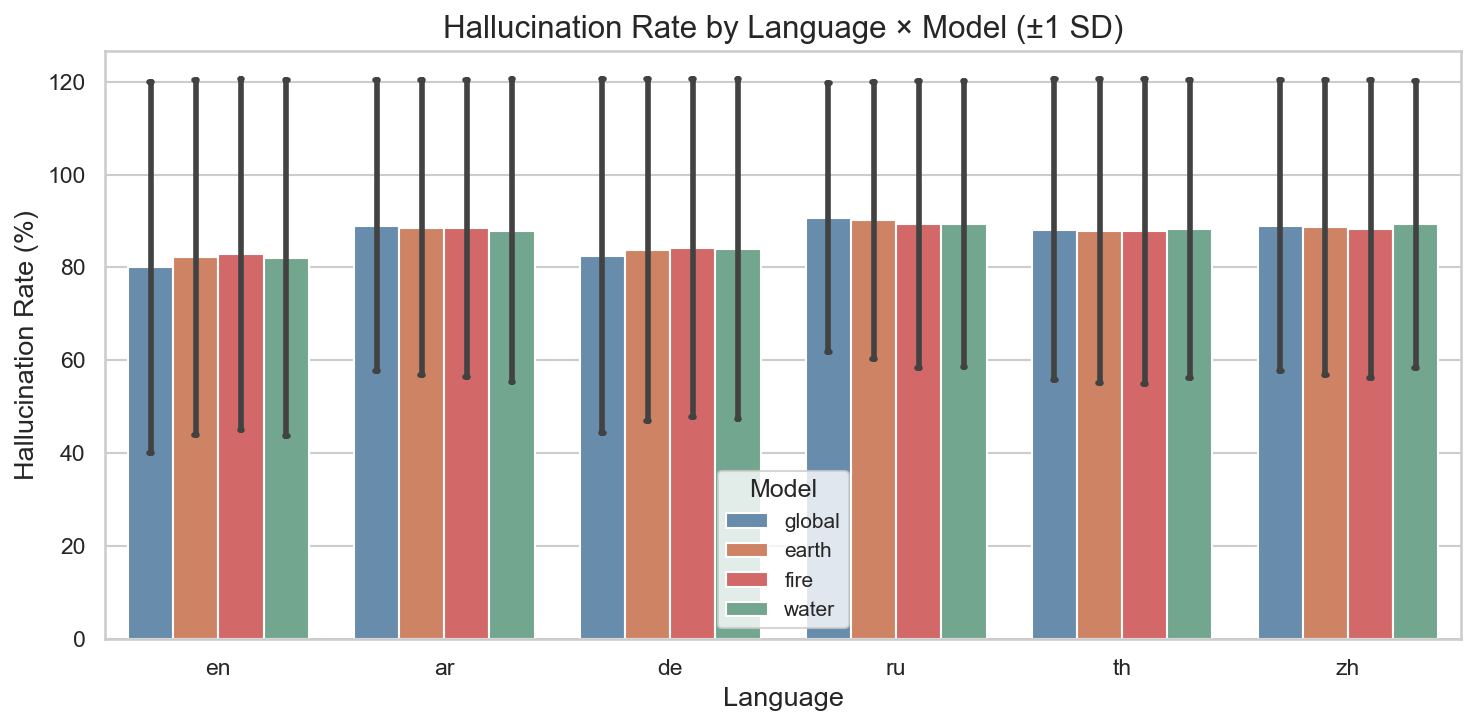

In [4]:
# Hallucination Rate by model × language (mean across reps, seaborn handles CI)
hr_lang_rep = mkqa_base.dropna(subset=["is_correct"]).copy()
hr_lang_rep["hallucination_rate"] = (1 - hr_lang_rep["is_correct"].astype(float)) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=hr_lang_rep, x="language", y="hallucination_rate", hue="model",
    palette=MODEL_PALETTE, hue_order=MODEL_ORDER, order=LANG_ORDER,
    errorbar="sd", capsize=0.05, ax=ax,
)
ax.set_title("Hallucination Rate by Language × Model (±1 SD)")
ax.set_ylabel("Hallucination Rate (%)")
ax.set_xlabel("Language")
ax.legend(title="Model")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "hr_by_lang_model.png")
plt.show()

## CMDR — Cross-Model Disagreement Rate

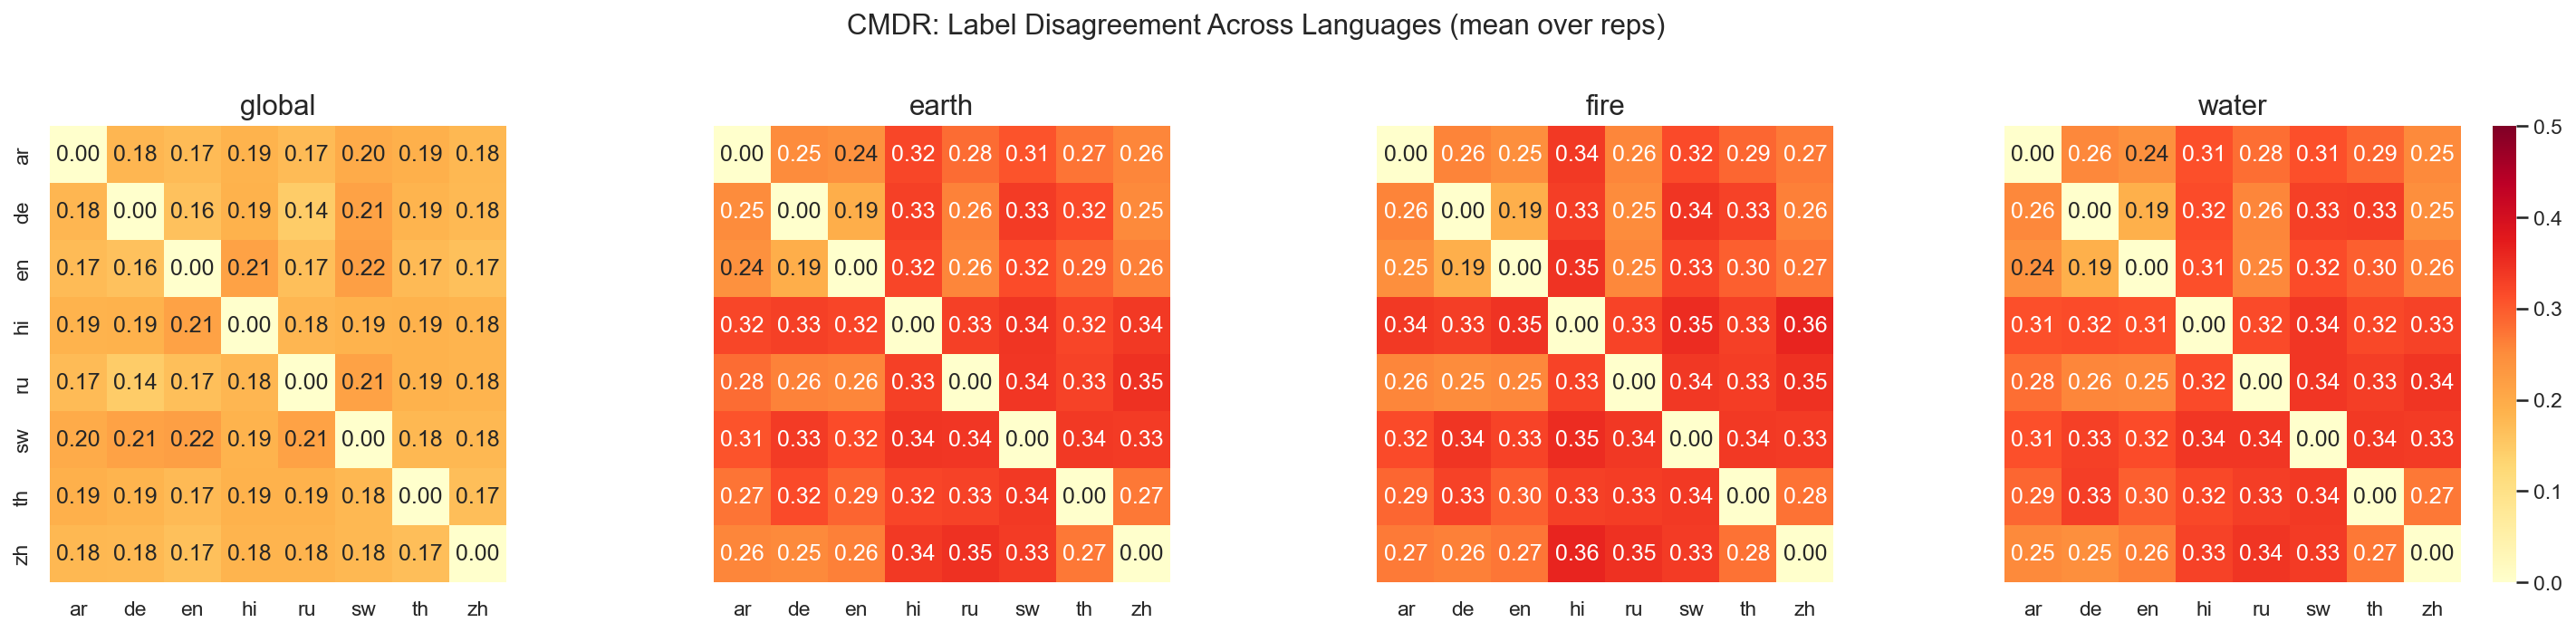

In [5]:
# CMDR across languages (per model): label disagreement between language pairs
# Average heatmaps across all reps
XNLI_LANGS = sorted(xnli_base["language"].unique())

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(5 * len(MODEL_ORDER), 4.5), sharey=True)

for ax, model in zip(axes, MODEL_ORDER):
    mdf = xnli_base[xnli_base["model"] == model]
    n_langs = len(XNLI_LANGS)
    disagree_all = []

    for rep in mdf["rep"].unique():
        rdf = mdf[mdf["rep"] == rep]
        pivot = rdf.pivot_table(index="sample_id", columns="language", values="parsed_label", aggfunc="first")
        disagree = pd.DataFrame(np.zeros((n_langs, n_langs)), index=XNLI_LANGS, columns=XNLI_LANGS)
        for l1, l2 in combinations(XNLI_LANGS, 2):
            if l1 in pivot.columns and l2 in pivot.columns:
                mask = pivot[l1].notna() & pivot[l2].notna()
                rate = (pivot.loc[mask, l1] != pivot.loc[mask, l2]).mean()
                disagree.loc[l1, l2] = rate
                disagree.loc[l2, l1] = rate
        disagree_all.append(disagree.values)

    mean_disagree = pd.DataFrame(
        np.mean(disagree_all, axis=0), index=XNLI_LANGS, columns=XNLI_LANGS
    )
    sns.heatmap(mean_disagree.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=0.5, ax=ax, cbar=model == MODEL_ORDER[-1],
                square=True)
    ax.set_title(model)

fig.suptitle("CMDR: Label Disagreement Across Languages (mean over reps)", fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cmdr_lang_heatmaps.png")
plt.show()

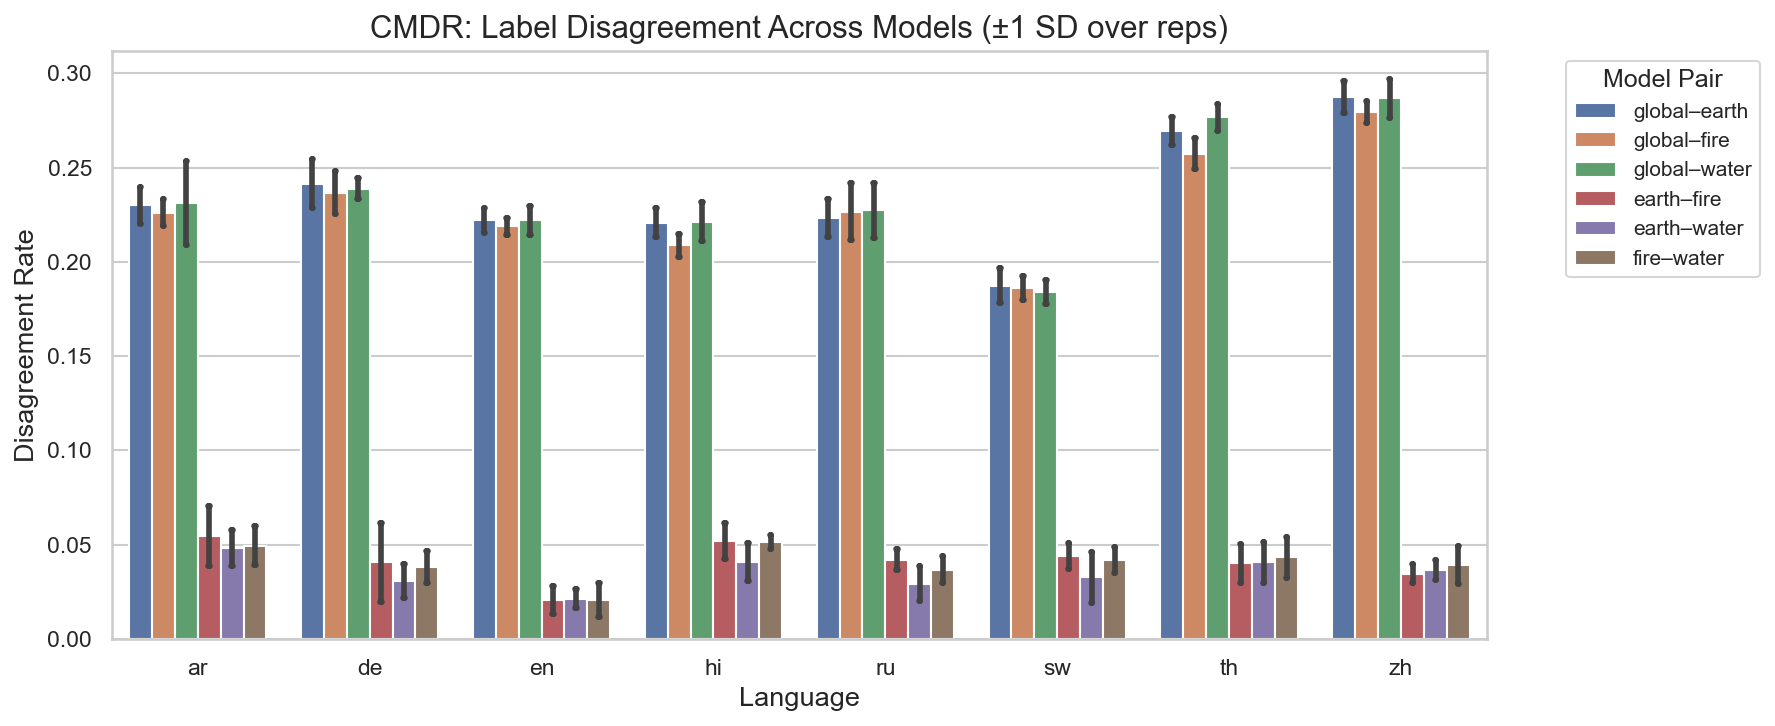

In [6]:
# CMDR across models: label disagreement between model pairs per language (all reps)
rows = []
for rep in xnli_base["rep"].unique():
    rdf = xnli_base[xnli_base["rep"] == rep]
    for lang in XNLI_LANGS:
        ldf = rdf[rdf["language"] == lang]
        pivot = ldf.pivot_table(index="sample_id", columns="model", values="parsed_label", aggfunc="first")
        for m1, m2 in combinations(MODEL_ORDER, 2):
            if m1 in pivot.columns and m2 in pivot.columns:
                mask = pivot[m1].notna() & pivot[m2].notna()
                rate = (pivot.loc[mask, m1] != pivot.loc[mask, m2]).mean()
                rows.append({"language": lang, "rep": rep, "pair": f"{m1}–{m2}", "disagreement": rate})

cmdr_models = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=cmdr_models, x="language", y="disagreement", hue="pair",
    order=XNLI_LANGS, errorbar="sd", capsize=0.05, ax=ax,
)
ax.set_title("CMDR: Label Disagreement Across Models (±1 SD over reps)")
ax.set_ylabel("Disagreement Rate")
ax.set_xlabel("Language")
ax.legend(title="Model Pair", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cmdr_model_pairs.png")
plt.show()

## AMR, SCS & CLC

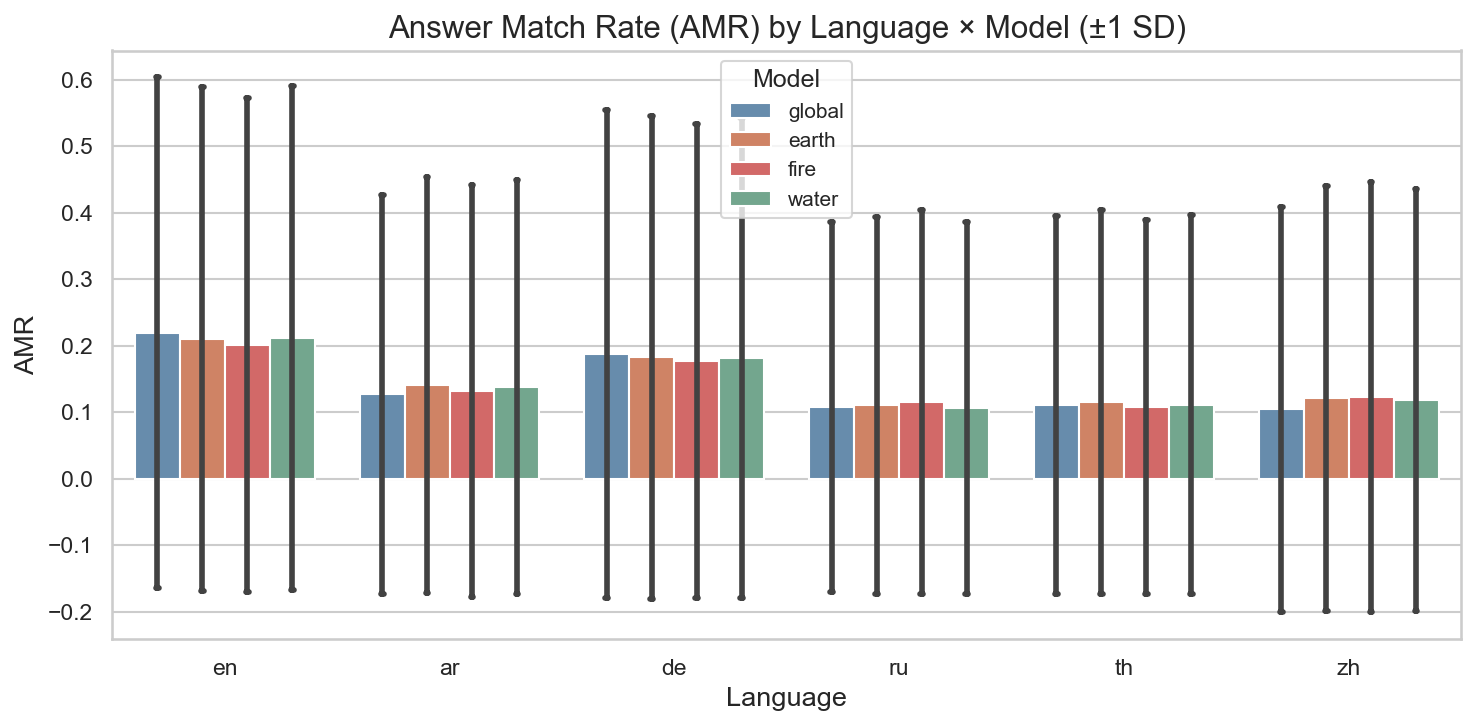

In [7]:
# AMR (Answer Match Rate)
def normalize_text(text):
    if not text:
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text


def answer_match(response, gold_answers):
    """Score response against a list of gold answer strings."""
    if not gold_answers:
        return None
    if not response:
        return 0.0
    r = normalize_text(response)
    best = 0.0
    for g_text in gold_answers:
        g = normalize_text(g_text)
        if not g:
            continue
        if g in r:
            return 1.0
        r_tokens = set(r.split())
        g_tokens = set(g.split())
        overlap = len(r_tokens & g_tokens)
        score = overlap / len(g_tokens) if g_tokens else 0.0
        best = max(best, score)
    return round(best, 4)


amr_df = mkqa_base.copy()
amr_df["amr"] = amr_df.apply(
    lambda row: answer_match(row["response_text"], row["gold_answers"]), axis=1
)
amr_df = amr_df.dropna(subset=["amr"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=amr_df, x="language", y="amr", hue="model",
    palette=MODEL_PALETTE, hue_order=MODEL_ORDER, order=LANG_ORDER,
    errorbar="sd", capsize=0.05, ax=ax,
)
ax.set_title("Answer Match Rate (AMR) by Language × Model (±1 SD)")
ax.set_ylabel("AMR")
ax.set_xlabel("Language")
ax.legend(title="Model")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "amr_by_lang_model.png")
plt.show()

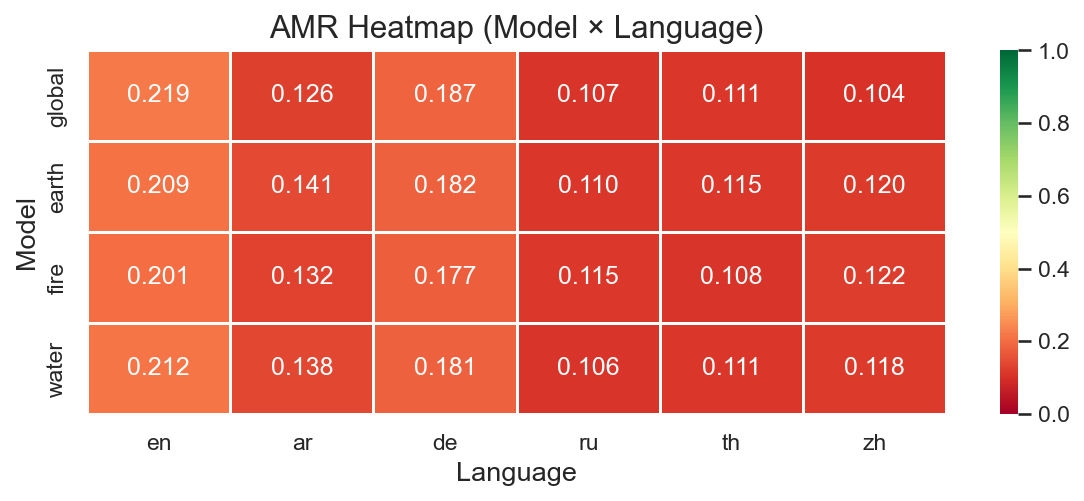

In [8]:
# AMR Heatmap (mean across all reps)
amr_lang = amr_df.groupby(["language", "model"])["amr"].mean().reset_index()
amr_pivot = amr_lang.pivot(index="model", columns="language", values="amr")
amr_pivot = amr_pivot.reindex(index=MODEL_ORDER, columns=LANG_ORDER)

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(
    amr_pivot, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0, vmax=1, ax=ax, linewidths=0.5,
)
ax.set_title("AMR Heatmap (Model × Language)")
ax.set_ylabel("Model")
ax.set_xlabel("Language")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "amr_heatmap.png")
plt.show()

### SCS — Semantic Consistency Score

Run `python compute_scs.py` to generate `results/scs_results.csv`, then execute the cell below to plot.

/var/folders/q6/kbk4hvwn5cl2y361hyy37_cr0000gp/T/ipykernel_20103/3840413194.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


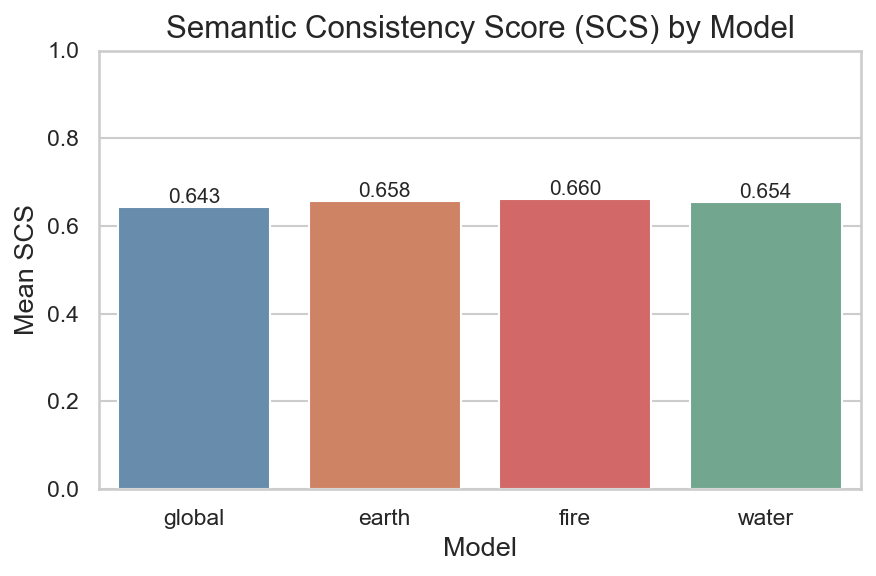

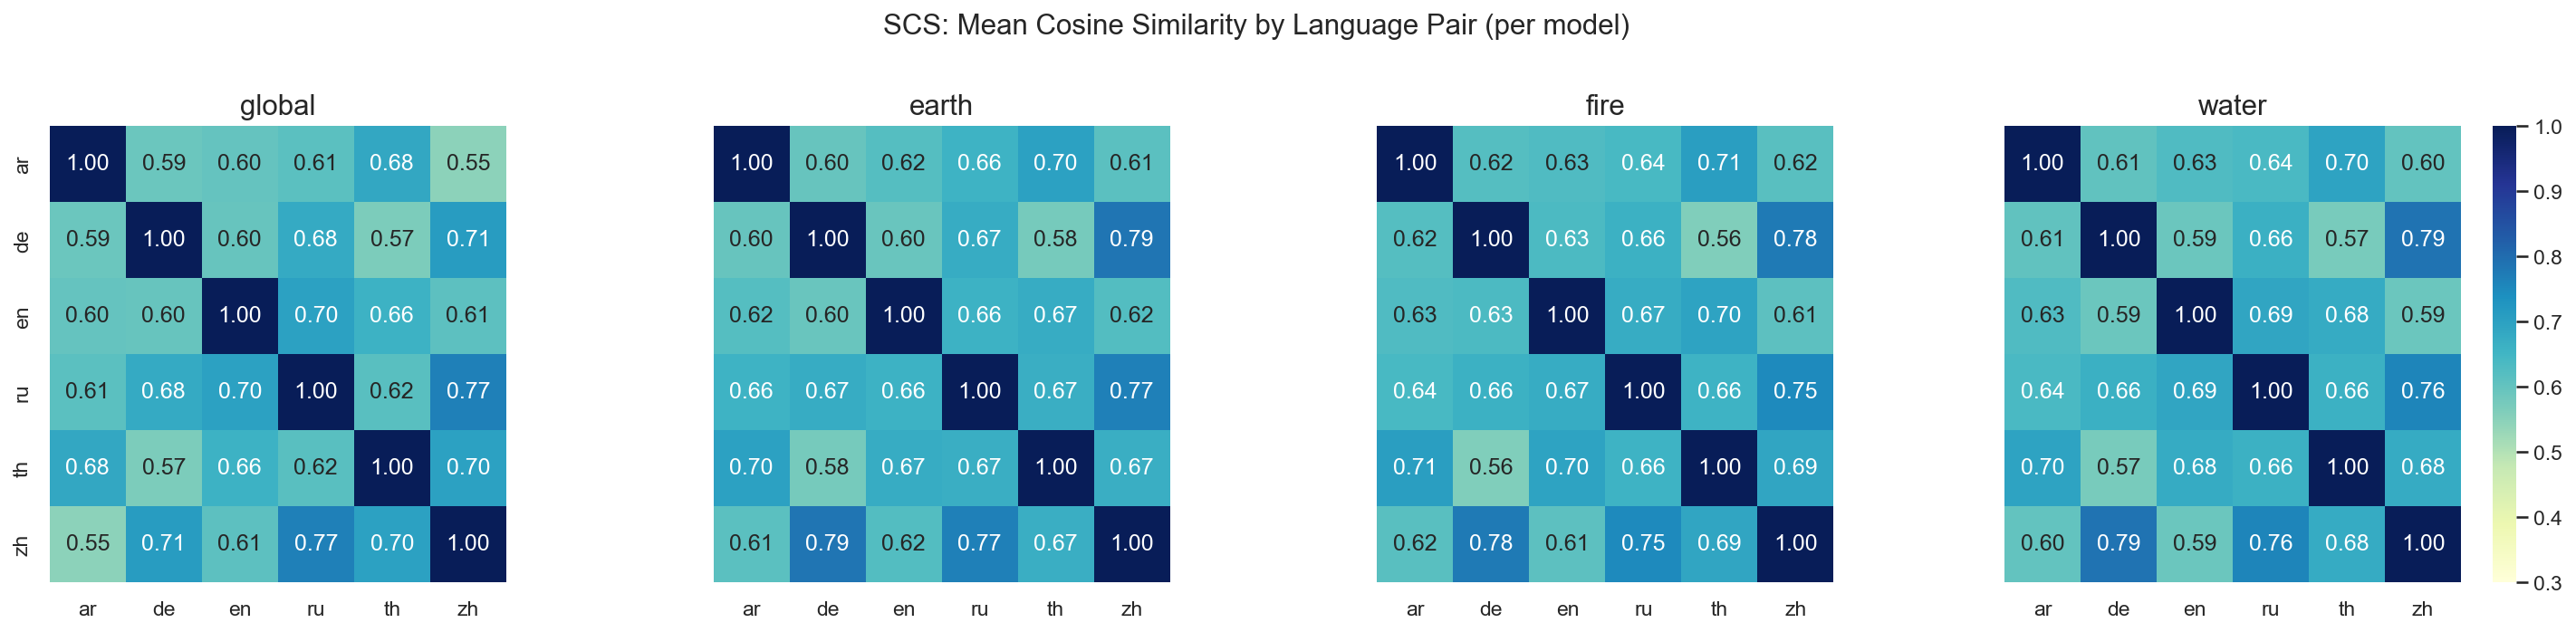

In [9]:
# SCS: load precomputed results
scs_path = Path("results/scs_results.csv")
scs_pairs_path = Path("results/scs_pairs.csv")

if not scs_path.exists():
    print(f"SCS results not found at {scs_path}. Run: python compute_scs.py")
else:
    scs_results = pd.read_csv(scs_path)
    scs_by_model = scs_results.groupby("model")["scs"].mean().reindex(MODEL_ORDER).reset_index()

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(
        data=scs_by_model, x="model", y="scs",
        palette=MODEL_PALETTE, order=MODEL_ORDER, ax=ax,
    )
    ax.set_title("Semantic Consistency Score (SCS) by Model")
    ax.set_ylabel("Mean SCS")
    ax.set_xlabel("Model")
    ax.set_ylim(0, 1)
    for bar in ax.patches:
        ax.annotate(f"{bar.get_height():.3f}",
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "scs_by_model.png")
    plt.show()

    # Language-pair heatmaps per model
    if scs_pairs_path.exists():
        scs_pairs = pd.read_csv(scs_pairs_path)
        pair_langs = sorted(set(scs_pairs["lang1"]) | set(scs_pairs["lang2"]))

        fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(5 * len(MODEL_ORDER), 4.5), sharey=True)
        for ax, model in zip(axes, MODEL_ORDER):
            mdf = scs_pairs[scs_pairs["model"] == model]
            mean_sim = mdf.groupby(["lang1", "lang2"])["similarity"].mean()
            mat = pd.DataFrame(np.ones((len(pair_langs), len(pair_langs))),
                               index=pair_langs, columns=pair_langs)
            for (l1, l2), val in mean_sim.items():
                mat.loc[l1, l2] = val
                mat.loc[l2, l1] = val
            sns.heatmap(mat.astype(float), annot=True, fmt=".2f", cmap="YlGnBu",
                        vmin=0.3, vmax=1.0, ax=ax, cbar=model == MODEL_ORDER[-1],
                        square=True)
            ax.set_title(model)

        fig.suptitle("SCS: Mean Cosine Similarity by Language Pair (per model)", fontsize=15, y=1.02)
        plt.tight_layout()
        fig.savefig(OUTPUT_DIR / "scs_lang_pair_heatmaps.png")
        plt.show()

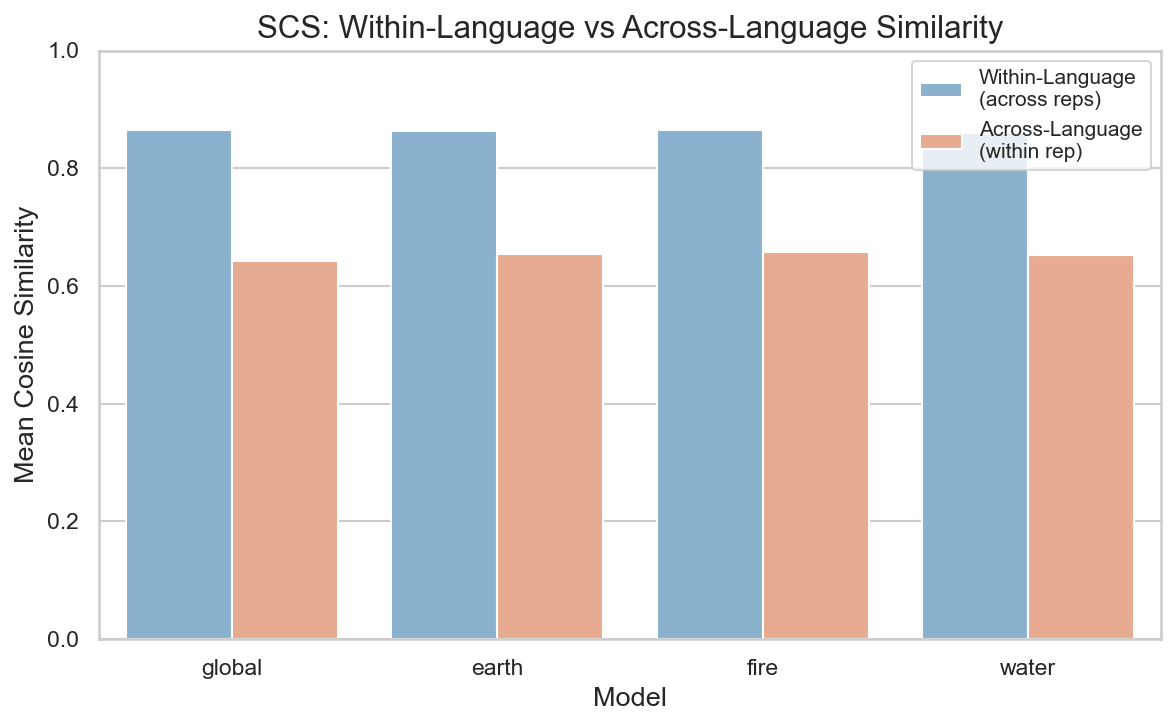

In [10]:
# SCS: Within-language similarity (across reps) vs Across-language similarity (within rep)
within_path = Path("results/scs_within_lang.csv")
scs_pairs_path = Path("results/scs_pairs.csv")

if not within_path.exists() or not scs_pairs_path.exists():
    print("Missing SCS CSVs. Run: python compute_scs.py")
else:
    within_df = pd.read_csv(within_path)
    scs_pairs = pd.read_csv(scs_pairs_path)

    # Within-language: mean similarity per model (same prompt, same lang, different reps)
    within_model = within_df.groupby("model")["mean_sim"].mean().reindex(MODEL_ORDER)

    # Across-language: mean similarity per model (same prompt, same rep, different langs)
    across_model = scs_pairs.groupby("model")["similarity"].mean().reindex(MODEL_ORDER)

    comp_df = pd.DataFrame({
        "model": MODEL_ORDER,
        "Within-Language\n(across reps)": within_model.values,
        "Across-Language\n(within rep)": across_model.values,
    }).melt(id_vars="model", var_name="Comparison", value_name="Cosine Similarity")

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=comp_df, x="model", y="Cosine Similarity", hue="Comparison",
        palette=["#7FB3D8", "#F4A582"], order=MODEL_ORDER, ax=ax,
    )
    ax.set_title("SCS: Within-Language vs Across-Language Similarity")
    ax.set_ylabel("Mean Cosine Similarity")
    ax.set_xlabel("Model")
    ax.set_ylim(0, 1)
    ax.legend(title="")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "scs_within_vs_across.png")
    plt.show()

### CLC — Cross-Language Consistency Score

$\text{CLC} = 0.6 \times \text{AMR} + 0.4 \times \text{SCS}_\text{lang}$

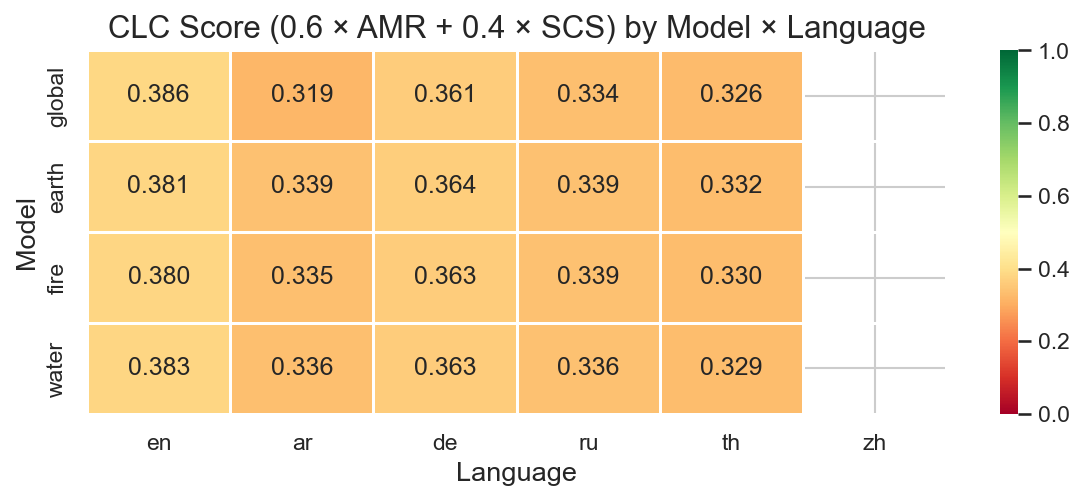

In [11]:
# CLC = 0.6 * AMR + 0.4 * SCS_lang (per model × language)
scs_pairs_path = Path("results/scs_pairs.csv")

if not scs_pairs_path.exists():
    print("Missing scs_pairs.csv. Run: python compute_scs.py")
else:
    scs_pairs = pd.read_csv(scs_pairs_path)

    # SCS per (model, language): average similarity of all pairs involving that language
    scs_lang_rows = []
    for (model, lang), _ in scs_pairs.groupby(["model", "lang1"]):
        mask = (scs_pairs["model"] == model) & (
            (scs_pairs["lang1"] == lang) | (scs_pairs["lang2"] == lang)
        )
        scs_lang_rows.append({
            "model": model,
            "language": lang,
            "scs_lang": scs_pairs.loc[mask, "similarity"].mean(),
        })
    scs_lang_df = pd.DataFrame(scs_lang_rows).drop_duplicates()

    # AMR per (model, language)
    amr_lang = amr_df.groupby(["model", "language"])["amr"].mean().reset_index()

    # Merge and compute CLC
    clc_df = amr_lang.merge(scs_lang_df, on=["model", "language"], how="inner")
    clc_df["clc"] = 0.6 * clc_df["amr"] + 0.4 * clc_df["scs_lang"]

    clc_pivot = clc_df.pivot(index="model", columns="language", values="clc")
    clc_pivot = clc_pivot.reindex(index=MODEL_ORDER, columns=LANG_ORDER)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    sns.heatmap(
        clc_pivot.astype(float), annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=0, vmax=1, ax=ax, linewidths=0.5,
    )
    ax.set_title("CLC Score (0.6 × AMR + 0.4 × SCS) by Model × Language")
    ax.set_ylabel("Model")
    ax.set_xlabel("Language")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "clc_heatmap.png")
    plt.show()

## PSS — Prompt Sensitivity Score

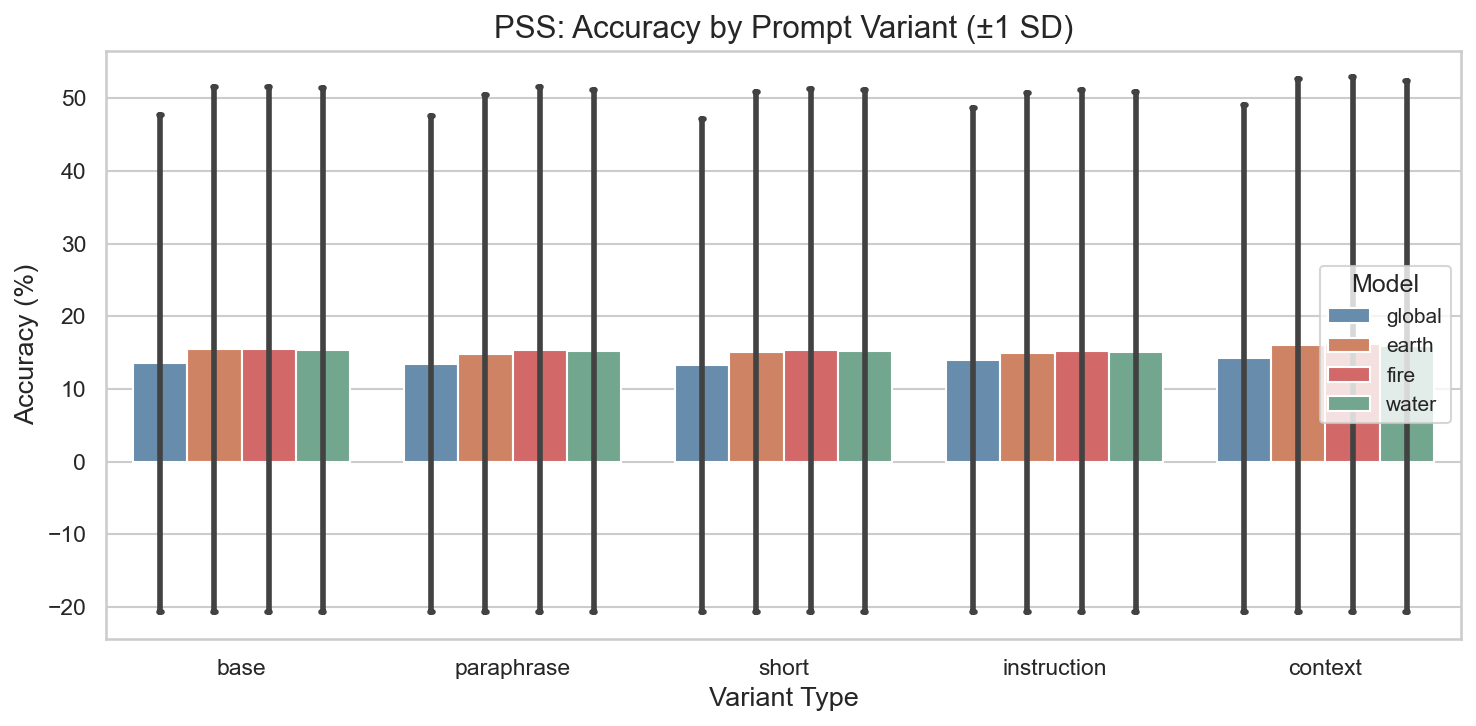

In [12]:
# PSS: Accuracy by variant type (all reps, with error bars)
VARIANT_ORDER = ["base", "paraphrase", "short", "instruction", "context"]

mkqa_pss["accuracy_pct"] = mkqa_pss["is_correct"].astype(float) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=mkqa_pss, x="variant_type", y="accuracy_pct", hue="model",
    palette=MODEL_PALETTE, hue_order=MODEL_ORDER, order=VARIANT_ORDER,
    errorbar="sd", capsize=0.05, ax=ax,
)
ax.set_title("PSS: Accuracy by Prompt Variant (±1 SD)")
ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Variant Type")
ax.legend(title="Model")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "pss_accuracy_by_variant.png")
plt.show()

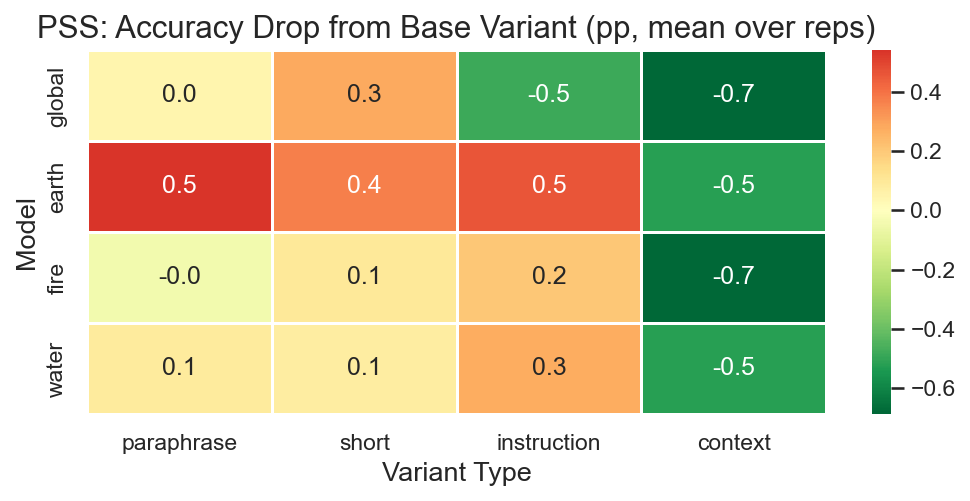

In [13]:
# PSS: Accuracy drop from base variant (mean across all reps)
base_acc = (
    mkqa_pss[mkqa_pss["variant_type"] == "base"]
    .groupby(["model", "language", "rep"])["is_correct"]
    .mean()
    .rename("base_accuracy")
    .reset_index()
)
all_acc = (
    mkqa_pss.groupby(["model", "language", "variant_type", "rep"])["is_correct"]
    .mean()
    .rename("accuracy")
    .reset_index()
)
all_acc = all_acc.merge(
    base_acc, on=["model", "language", "rep"], how="left"
)
all_acc["drop"] = (all_acc["base_accuracy"] - all_acc["accuracy"]) * 100

# Average drop across languages and reps
drop_summary = (
    all_acc[all_acc["variant_type"] != "base"]
    .groupby(["model", "variant_type"])["drop"]
    .mean()
    .reset_index()
)
drop_pivot = drop_summary.pivot(index="model", columns="variant_type", values="drop")
drop_pivot = drop_pivot.reindex(
    index=MODEL_ORDER,
    columns=[v for v in VARIANT_ORDER if v != "base"],
).astype(float)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(
    drop_pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
    center=0, ax=ax, linewidths=0.5,
)
ax.set_title("PSS: Accuracy Drop from Base Variant (pp, mean over reps)")
ax.set_ylabel("Model")
ax.set_xlabel("Variant Type")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "pss_accuracy_drop_heatmap.png")
plt.show()